# Problem:

A company must determine how many boats to be produced during each of the next four quarters, where demand is known. They must meet demands on time. At the beginning of the first quarter there are $10$ boats in stock. Also, at the beginning of each quarter they must decide how many boats to be produced during the quarter. During each quarter up to $40$ boats can be produced with regular-time labour at a total cost of $\$400$ per boat. With over-time work during the quarter, additional boats can be produced at a total cost of $\$450$ per boat. At the end of each quarter a holding cost of $\$20$ per boat is incurred for any boat not sold. Find the optimal production level for each quarter to minimise the total costs.

<img src=attachment:792e422e-9e0f-4688-9938-fb9ec05b133d.png  width="400" height="200">
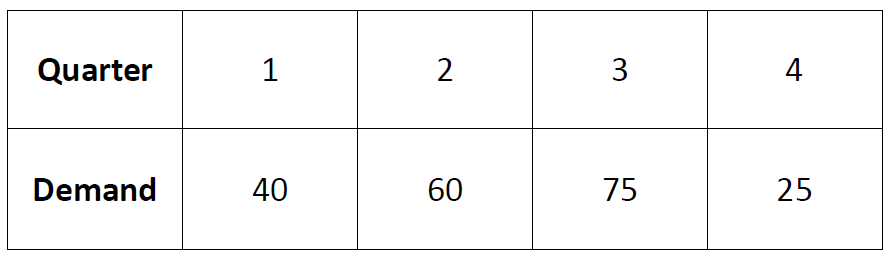


# Mathematical formulation

$$\min z = c_r\sum_{t\in T} x_t + c_o\sum_{i\in T} y_t + c_h\sum_{i\in T} i_t$$

$$\text{subject to:}$$

$$i_t = i_{t-1} + x_t + y_t - d_t, ~ ~ \forall t \in T$$

$$x_t \leq p_{max}, ~ \forall t \in T$$

$$x_t \geq 0, ~ y_t \geq 0, ~ i_t \geq 0, ~ \forall t \in T$$


$$d = \{40, 60, 75, 25\}, ~ ~ i_0 = 10, ~ ~ p_{max} = 40$$

$$c_r = 400, ~ ~ c_o = 450 ~ ~ c_h = 20$$


In [2]:
from gurobipy import *

P = Model('production')

# ------------------- data
quarters = 4
demand = [40, 60, 75, 25]
initialInventory = 10
p_max = 40
c_r = 400
c_o = 450
c_h = 20


# ------------------- variables
x = {}
y = {}
i = {}
for t in range(4):
    x[t] = P.addVar(vtype=GRB.CONTINUOUS)
    y[t] = P.addVar(vtype=GRB.CONTINUOUS)
    i[t] = P.addVar(vtype=GRB.CONTINUOUS)


# ------------------- constraints
for t in range(quarters):
    if t == 0:
        P.addConstr(i[t] == initialInventory + x[t] + y[t] - demand[t])
    else:
        P.addConstr(i[t] == i[t-1] + x[t] + y[t] - demand[t])

for t in range(quarters):
    P.addConstr(x[t] <= 40)

# ------------------- objective function
P.setObjective(c_r * sum(x[t] for t in range(quarters)) 
               + c_o * sum(y[t] for t in range(quarters)) 
               + c_h * sum(i[t] for t in range(quarters)), GRB.MINIMIZE)

P.optimize()

print("----------------------------------------------------")
for t in range(quarters):
    print("regular-time production in quarter %s is: " % (t+1), x[t].x)
    print("over-time production in quarter %s is: " % (t+1), y[t].x)
    print("items in stock at the end of quarter %s is: " % (t+1), i[t].x)
print("Objective function (total cost) is: ", P.objVal)



Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1265U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 8 rows, 12 columns and 19 nonzeros
Model fingerprint: 0x32911ba0
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+01, 5e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+01, 8e+01]
Presolve removed 4 rows and 0 columns
Presolve time: 0.02s
Presolved: 4 rows, 12 columns, 15 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   4.750000e+01   0.000000e+00      0s
       6    7.8450000e+04   0.000000e+00   0.000000e+00      0s

Solved in 6 iterations and 0.05 seconds (0.00 work units)
Optimal objective  7.845000000e+04
----------------------------------------------------
regular-time production in quarter 1 is:  40.0
over-time production 